/Users/rehanhussain/anaconda3/envs/cifar_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CIFAR-10 data...


Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 452533.20 examples/s]


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)

Training model: ANN Baseline


/Users/rehanhussain/anaconda3/envs/cifar_env/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2291 - loss: 2.0600 - val_accuracy: 0.3005 - val_loss: 1.9080
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2784 - loss: 1.9418 - val_accuracy: 0.3319 - val_loss: 1.8408
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2918 - loss: 1.9103 - val_accuracy: 0.3494 - val_loss: 1.8181
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3033 - loss: 1.8859 - val_accuracy: 0.3295 - val_loss: 1.8352
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3095 - loss: 1.8763 - val_accuracy: 0.3657 - val_loss: 1.8272
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3132 - loss: 1.8682 - val_accuracy: 0.3734 - val_loss: 1.8066
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3181 - loss: 1.8507 - val_accuracy: 0.3852 - val_loss: 1.7748
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3238 - loss: 1.

/Users/rehanhussain/anaconda3/envs/cifar_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 94ms/step - accuracy: 0.4879 - loss: 1.4774 - val_accuracy: 0.6263 - val_loss: 1.0530
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 159s 101ms/step - accuracy: 0.6810 - loss: 0.9246 - val_accuracy: 0.6355 - val_loss: 1.0688
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 162s 104ms/step - accuracy: 0.7380 - loss: 0.7652 - val_accuracy: 0.6946 - val_loss: 0.8933
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.7821 - loss: 0.6470 - val_accuracy: 0.7654 - val_loss: 0.6625
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.8137 - loss: 0.5536 - val_accuracy: 0.7837 - val_loss: 0.6471
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.8394 - loss: 0.4820 - val_accuracy: 0.8162 - val_loss: 0.5511
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 128ms/step - accuracy: 0.8637 - loss: 0.4083 - val_accuracy: 0.8165 - val_loss: 0.5709
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 130ms/step - acc

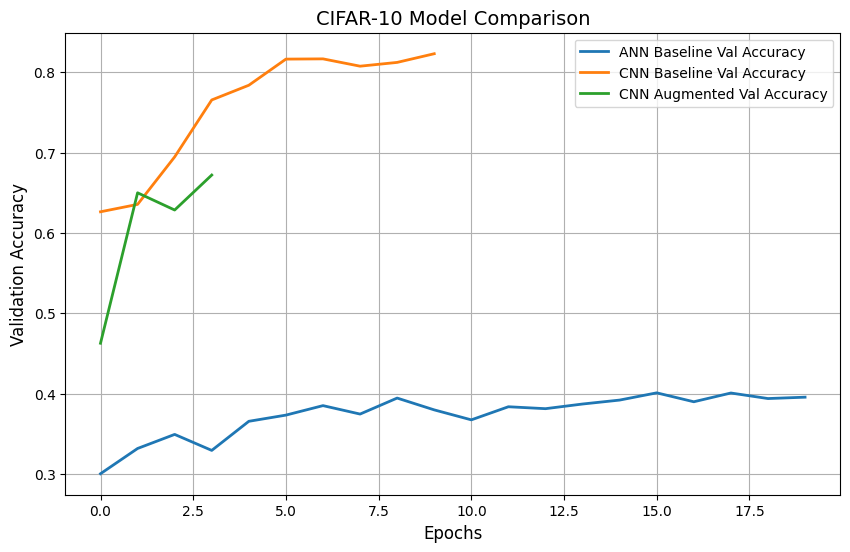


Final Test Evaluation Scores:
ANN Baseline -> Accuracy: 0.4011, Loss: 1.6946
CNN Baseline -> Accuracy: 0.8162, Loss: 0.5511
CNN Augmented -> Accuracy: 0.4628, Loss: 1.5508


In [4]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.callbacks import EarlyStopping
from datasets import load_dataset
import numpy as np

# Load the CIFAR-10 dataset
print("Loading CIFAR-10 data...")
hf_dataset = load_dataset("uoft-cs/cifar10")

X_train = np.array([np.array(x["img"]) for x in hf_dataset["train"]])
y_train = np.array(hf_dataset["train"]["label"]).reshape(-1, 1)

X_test = np.array([np.array(x["img"]) for x in hf_dataset["test"]])
y_test = np.array(hf_dataset["test"]["label"]).reshape(-1, 1)

# Normalize pixel values to be between 0.0 and 1.0
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


def build_ann():
    return models.Sequential(
        [
            layers.Flatten(input_shape=(32, 32, 3)),
            layers.Dense(512, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(10, activation="softmax"),
        ]
    )


def build_cnn():
    return models.Sequential(
        [
            # First layer block
            layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            # Second layer block (increasing filters)
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            # Third layer block
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            # Dense layers for final classification
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(10, activation="softmax"),
        ]
    )


def build_augmented_cnn():
    # Define the augmentation steps
    data_augmentation = models.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
        ]
    )
    
    # Build the model with augmentation layer included at the front
    return models.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            data_augmentation,
            
            # Same CNN architecture as above
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(10, activation="softmax"),
        ]
    )


# --- Training Configuration ---
# Use early stopping to prevent overfitting if the validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=4, 
    restore_best_weights=True
)

model_builders = {
    "ANN Baseline": build_ann, 
    "CNN Baseline": build_cnn, 
    "CNN Augmented": build_augmented_cnn
}

histories = {}
final_scores = {}

# Loop through all 3 models to compile and run them
for name, builder_func in model_builders.items():
    print(f"\nTraining model: {name}")
    
    keras.backend.clear_session()
    
    model = builder_func()
    model.compile(
        optimizer="adam", 
        loss="sparse_categorical_crossentropy", 
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=1,
    )
    histories[name] = history.history["val_accuracy"]
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    final_scores[name] = (test_acc, test_loss)
    
    del model


# --- Plotting Results ---
plt.figure(figsize=(10, 6))

for name, val_acc in histories.items():
    plt.plot(val_acc, label=f"{name} Val Accuracy", linewidth=2)

plt.title("CIFAR-10 Model Comparison", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Final evaluation on the test set
print("\nFinal Test Evaluation Scores:")
for name, (acc, loss) in final_scores.items():
    print(f"{name} -> Accuracy: {acc:.4f}, Loss: {loss:.4f}")